[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb04_cross_family.ipynb)

In [1]:
# Setup. On Colab this fetches the repo (data, results, replayable LLM cache); locally it does nothing.
# No API keys or paid calls are needed anywhere in this notebook.
import os, subprocess, sys
if 'google.colab' in sys.modules:
    REPO = '/content/llm-regime-allocator'
    if not os.path.exists(REPO):
        subprocess.run(['git', 'clone', '-q', '--depth', '1', 'https://github.com/FranQuant/llm-regime-allocator.git', REPO], check=True)
    sys.path.insert(0, f'{REPO}/src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lra import viz
viz.apply_style()

# nb04 — Is it Claude, or LLMs? Three more model families

**Question.** nb02 and nb03 rest on one model. If the blinded result is a property of language models rather than of Sonnet, other families should reproduce it, and blinding should hide the date from them too. Read from `scripts/score_phase8.py` output; no API calls.

## Setup

| Model | Provider | Knowledge cutoff (provider docs) |
|---|---|---|
| Sonnet 5.5 (from nb03) | Anthropic | Jun 2026 |
| GPT-6.1-sol | OpenAI | Apr 2026 |
| Gemini 3.8 Flash | Google | Mar 2026 |
| GLM-5.3 (open weights) | Zhipu | not published |

Same blinded prompt, same 217 scored months, provider-default reasoning.

**Pre-registered test** (`configs/phase8.toml`, committed before the first paid call). A model *replicates* if its Brier is below uniform (0.750), the 95% interval of the gap excludes zero, and it beats the best ML model on the same blinded inputs (0.871).

**Agreement** between two models is the total-variation distance $\mathrm{TV}(p,q)=\tfrac12\sum_k|p_k-q_k|$: 0 for identical answers, 1 for disjoint ones.

In [2]:
P8 = viz.RESULTS / 'phase8'
M = list(viz.MODEL_COLORS)
NAME = {**viz.MODEL_NAMES, 'ensemble_4': 'average of the four'}
pr = pd.read_csv(P8 / 'primary.csv').set_index('model')

## 1. Every family beats ML; only two clear uniform

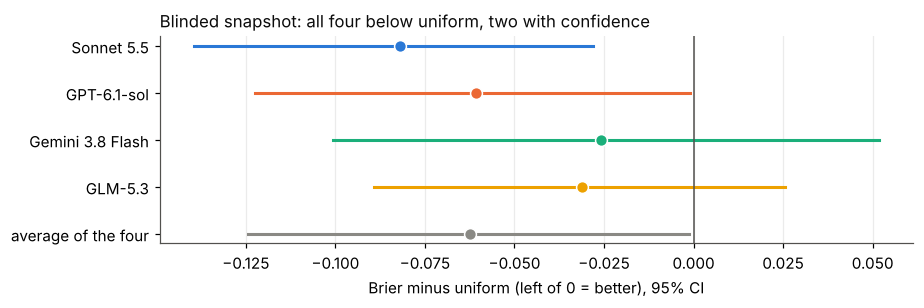

,brier,minus_uniform,ci_lo,ci_hi,hit_rate,replicates
model,,,,,,
Sonnet 5.5,0.668,-0.082,-0.140,-0.028,46%,True
GPT-6.1-sol,0.689,-0.061,-0.122,-0.001,40%,True
Gemini 3.8 Flash,0.724,-0.026,-0.101,0.052,46%,False
GLM-5.3,0.719,-0.031,-0.089,0.025,39%,False
average of the four,0.688,-0.062,-0.124,-0.001,43%,True


In [3]:
t = pr.loc[M + ['ensemble_4']]
fig, ax = plt.subplots(figsize=(8.5, 2.9))
viz.ci_forest(ax, t.minus_uniform, t.ci_lo, t.ci_hi, [NAME[k] for k in t.index],
              [viz.MODEL_COLORS.get(k, viz.GREYS['ml']) for k in t.index],
              xlabel='Brier minus uniform (left of 0 = better), 95% CI')
ax.set_title('Blinded snapshot: all four below uniform, two with confidence'); plt.tight_layout(); plt.show()
viz.fmt(t.rename(index=NAME)[['brier', 'minus_uniform', 'ci_lo', 'ci_hi', 'hit_rate', 'replicates']], pct=['hit_rate'])

**Reading.** **Key finding:** all four families forecast the blinded snapshot better than uniform (0.668–0.724) and far better than ML on the same inputs (0.871), so the LLM-over-ML gap is not a Claude artefact. Only Sonnet and GPT pass the full test, GPT by a hair (upper bound −0.001). Averaging the four (0.688) does not beat Sonnet alone: their errors overlap. First-release labels improve every model by 0.02–0.04 and change no ranking.

## 2. Blinding does not hide the date from GPT

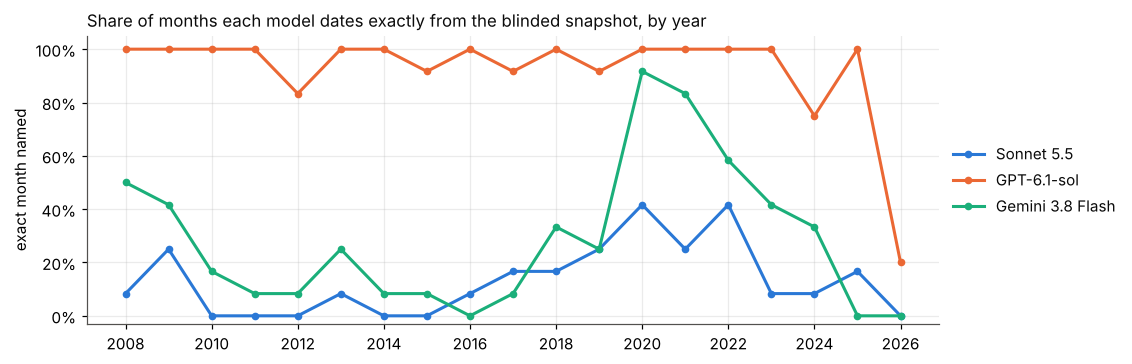

,status,exact_month,within_12m,n_datable,n_undatable
model,,,,,
Sonnet 5.5,complete,14%,50%,108,109
GPT-6.1-sol,complete,94%,98%,216,1
Gemini 3.8 Flash,complete,29%,60%,134,83
GLM-5.3,not completed (reasoning exceeded the output cap),–,–,–,–


In [4]:
fig, ax = plt.subplots(figsize=(10, 3.4))
for k in M[:3]:
    e = viz.read(f'results/llm/{k}/date_probe_blinded_run0.csv')['error_months'].loc['2008':]
    s = (e == 0).groupby(e.index.year).mean()
    ax.plot(s.index, s, marker='o', ms=4, color=viz.MODEL_COLORS[k], label=viz.MODEL_NAMES[k])
ax.set_xticks(range(2008, 2027, 2)); ax.set_ylim(-0.03, 1.05)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1, decimals=0))
ax.set_ylabel('exact month named'); ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.set_title('Share of months each model dates exactly from the blinded snapshot, by year'); plt.show()
pb = pd.read_csv(P8 / 'probe.csv').set_index('model').rename(index=NAME)
viz.fmt(pb[['status', 'exact_month', 'within_12m', 'n_datable', 'n_undatable']], pct=['exact_month', 'within_12m'],
        d0=['n_datable', 'n_undatable'])

**Reading.** **Key finding:** GPT names the exact month in 94% of blinded snapshots (Sonnet 14%, Gemini 29%), and it stops being able to from early 2026, near its April 2026 cutoff: the signature of memory, not of a general dating skill. GPT's pass in section 1 is therefore not clean evidence. GLM's probe never completed (it reasoned past the output cap at 8k and 32k tokens), so its memory is unmeasured.

## 3. The portfolios

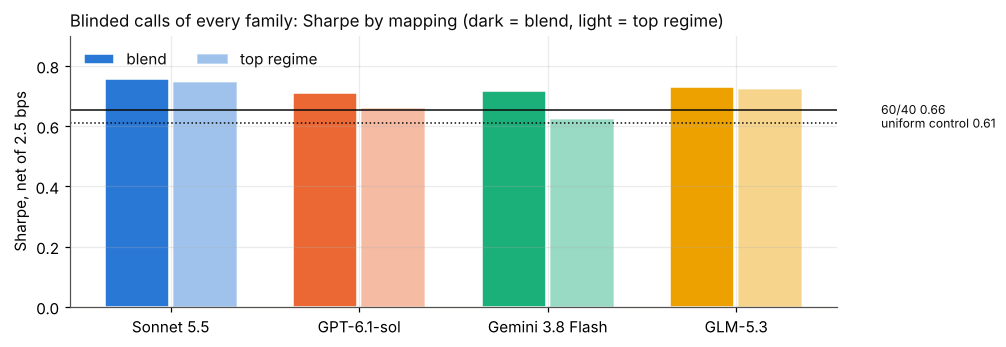

,blend,top regime,max drawdown (blend)
Sonnet 5.5,0.76,0.75,-16%
GPT-6.1-sol,0.71,0.66,-19%
Gemini 3.8 Flash,0.72,0.62,-19%
GLM-5.3,0.73,0.72,-19%


In [5]:
met = pd.read_csv(viz.RESULTS / 'phase5' / 'metrics.csv'); met = met[met.cost_bps == 2.5].set_index('strategy')
key = {'claude_sonnet': 'llm_sonnet_blinded', 'gpt_sol': 'llm_gpt_sol_blinded',
       'gemini_flash': 'llm_gemini_flash_blinded', 'glm': 'llm_glm_blinded'}
pf = pd.DataFrame({viz.MODEL_NAMES[m]: {'blend': met.loc[f'playbook__{k}', 'sharpe'],
                                       'top regime': met.loc[f'playbook_top__{k}', 'sharpe'],
                                       'max drawdown (blend)': met.loc[f'playbook__{k}', 'max_drawdown']}
                   for m, k in key.items()}).T
fig, ax = plt.subplots(figsize=(9, 3.2))
x = np.arange(4)
for i, (col, a) in enumerate([('blend', 1.0), ('top regime', 0.45)]):
    ax.bar(x + (i - 0.5) * 0.36, pf[col], 0.34, color=[viz.MODEL_COLORS[m] for m in M], alpha=a,
           label=col, edgecolor='white')
for v, lab, ls in [(met.loc['sixty_forty', 'sharpe'], '60/40', '-'), (met.loc['playbook__uniform', 'sharpe'], 'uniform control', ':')]:
    ax.axhline(v, color=viz.INK, lw=1, ls=ls); ax.text(3.75, v, f' {lab} {v:.2f}', va='center', fontsize=8)
ax.set_xticks(x, pf.index); ax.set_ylim(0, 0.9); ax.set_ylabel('Sharpe, net of 2.5 bps')
ax.legend(loc='upper left', ncol=2); ax.set_title('Blinded calls of every family: Sharpe by mapping (dark = blend, light = top regime)')
plt.show()
viz.fmt(pf, d2=['blend', 'top regime'], pct=['max drawdown (blend)'])

**Reading.** All four blended playbooks land at Sharpe 0.71–0.76 with drawdowns of −16% to −19%, against 0.66 and −32% for 60/40 and 0.61 for the control; none of the four differences from the control has an interval that excludes zero (`results/phase8/portfolios.csv`). The top-regime mapping is noisier across families (0.62–0.75): committing to one regime amplifies each model's errors.

## 4. Where the families agree

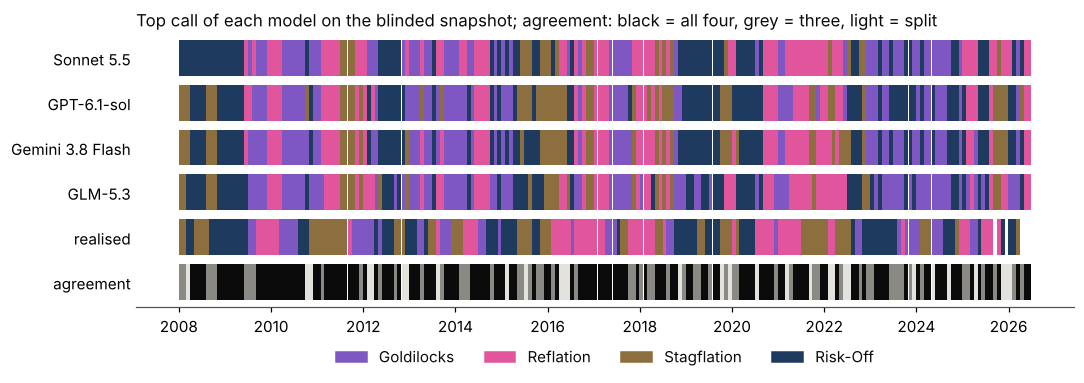

,months,majority call right
all four agree,132,45%
three or fewer,85,42%


In [6]:
calls = pd.DataFrame({m: viz.read(f'results/llm/{m}/blinded_run0.csv')[viz.REGIMES].idxmax(axis=1) for m in M}).dropna()
real = viz.read('results/baselines/regimes.csv')['realised_forward']
n_agree = calls.apply(lambda r: r.value_counts().iloc[0], axis=1)
fig, ax = plt.subplots(figsize=(11, 3.2))
rows = [(viz.MODEL_NAMES[m], calls[m]) for m in M] + [('realised', real.reindex(calls.index))]
for i, (lab, s) in enumerate(rows[::-1]):
    viz.regime_strip(ax, s, y0=i + 1.15, height=0.8)
shade = n_agree.map({4: viz.INK, 3: viz.GRID, 2: '#e4e2dc'})
ax.bar(calls.index, 0.8, width=31, bottom=0.15, color=shade, align='edge', linewidth=0)
ax.set_yticks([0.55] + [i + 1.55 for i in range(len(rows))], ['agreement'] + [r[0] for r in rows[::-1]])
ax.set_ylim(0, len(rows) + 1.05); ax.grid(False); ax.spines['left'].set_visible(False); ax.tick_params(axis='y', length=0)
ax.set_title('Top call of each model on the blinded snapshot; agreement: black = all four, grey = three, light = split')
viz.regime_legend(ax, anchor=(0.5, -0.1)); plt.show()
y = real.reindex(calls.index); lab = y.notna(); maj = calls.mode(axis=1)[0]
pd.DataFrame({g: {'months': int((mask & lab).sum()), 'majority call right': (maj[mask & lab] == y[mask & lab]).mean()}
              for g, mask in [('all four agree', n_agree == 4), ('three or fewer', n_agree < 4)]}).T.pipe(viz.fmt, pct=['majority call right'], d0=['months'])

**Reading.** The four families give the same top call in 60% of months (134 of 222), and they disagree most in transitions such as 2015, 2019 and 2022. Agreement is not a reliability signal: when all four agree the shared call is right 45% of the time, against 42% when they split.

## 5. Stability and agreement in numbers

In [7]:
v = pd.read_csv(P8 / 'variance.csv').set_index('model').rename(index=NAME)
viz.fmt(v[['n_scored', 'brier_run0', 'brier_run1', 'mean_abs_dp', 'same_top_regime']], pct=['same_top_regime'], d0=['n_scored'])

,n_scored,brier_run0,brier_run1,mean_abs_dp,same_top_regime
model,,,,,
GPT-6.1-sol,54,0.681,0.663,0.021,95%
Gemini 3.8 Flash,54,0.732,0.721,0.025,96%
GLM-5.3,54,0.718,0.729,0.049,86%


In [8]:
a = pd.read_csv(P8 / 'agreement.csv')
ag = pd.DataFrame(np.nan, index=[NAME[m] for m in M], columns=[NAME[m] for m in M])
for _, r in a.iterrows():
    ag.loc[NAME[r.a], NAME[r.b]] = ag.loc[NAME[r.b], NAME[r.a]] = r.same_top_regime
viz.fmt(ag.rename_axis('same top regime'), pct=list(ag.columns))

,Sonnet 5.5,GPT-6.1-sol,Gemini 3.8 Flash,GLM-5.3
same top regime,,,,
Sonnet 5.5,–,74%,81%,76%
GPT-6.1-sol,74%,–,86%,72%
Gemini 3.8 Flash,81%,86%,–,76%
GLM-5.3,76%,72%,76%,–


**Reading.** For the three new models, a second run on every fourth month moves probabilities by 2–5 points and keeps the top regime in 86–96% of months, so single runs are not noise-dominated. The families agree on the top regime in 72–86% of months (TV distance 0.12–0.17).

## What we can and cannot claim

- **Replicates across families:** every LLM reads the blinded snapshot better than ML on identical inputs, and every LLM playbook has a lower drawdown than 60/40.
- **Does not replicate cleanly:** beating uniform with confidence. Sonnet does; GPT does but dates almost every month; Gemini and GLM do not.
- **Blinding is not model-proof.** A backtest of an LLM forecaster should report a date-recovery probe per model. GLM's is missing.

## Next

No backtest can separate reading from remembering for these models. nb05 edits the figures and watches whether the answer follows.